In [77]:
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt

file: Path = Path(r"D:\Members\JiseongOh\251128_XFEL\analysis\testing_dark\processed_data\run=020\scan=001\run=0020_scan=0001_raw.npz")
raw_imgs = np.load(file)["poff"]
print(f"Raw images shape: {raw_imgs.shape}")
print(f"Raw images max: {raw_imgs.max()}")
print(f"Raw images mean: {raw_imgs.mean()}")

fig, ax = plt.subplots(1, 1, figsize=(10, 8))
ax.imshow(np.log1p(raw_imgs.sum(0)))
ax.set_title("Raw Images Sum")

file: Path = Path(r"D:\Members\JiseongOh\251128_XFEL\analysis\testing_dark\processed_data\run=021\scan=001\run=0020_scan=0001_sub_dark.npz")
subdark_imgs = np.load(file)["pon"]
print(f"Subtracted dark images shape: {subdark_imgs.shape}")
print(f"Subtracted dark images max: {subdark_imgs.max()}")
print(f"Subtracted dark images mean: {subdark_imgs.mean()}")

file: Path = Path(r"D:\Members\JiseongOh\251128_XFEL\analysis\testing_dark\processed_data\run=021\scan=001\run=0020_scan=0001_thresh4.npz")
thresh_imgs = np.load(file)["pon"]
print(f"Threshed images shape: {thresh_imgs.shape}")
print(f"Threshed images max: {thresh_imgs.max()}")
print(f"Threshed images mean: {thresh_imgs.mean()}")

fig, ax = plt.subplots(1, 1, figsize=(10, 8))
ax.imshow(np.log1p(thresh_imgs.sum(0)))
ax.set_title("Threshed Images Sum")

FileNotFoundError: [Errno 2] No such file or directory: 'D:\\Members\\JiseongOh\\251128_XFEL\\analysis\\testing_dark\\processed_data\\run=020\\scan=001\\run=0020_scan=0001_raw.npz'

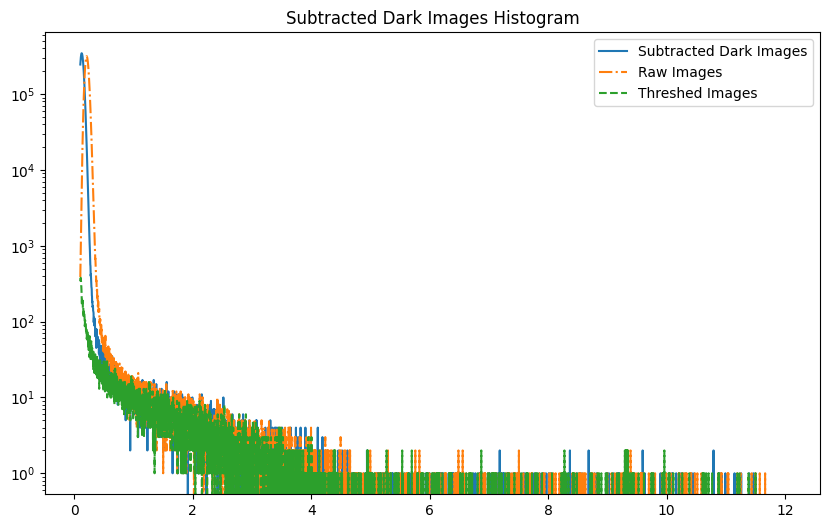

In [140]:
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt

raw_hist, raw_bin_edges = np.histogram(raw_imgs, bins=5000, range=(0.1, 12))
sd_hist, sd_bin_edges = np.histogram(subdark_imgs, bins=5000, range=(0.1, 12))
thresh_hist, thresh_bin_edges = np.histogram(thresh_imgs, bins=5000, range=(0.1, 12))
fig, ax = plt.subplots(1, 1, figsize=(10, 6))
ax.plot(sd_bin_edges[:-1], sd_hist, label="Subtracted Dark Images")
ax.plot(raw_bin_edges[:-1], raw_hist, "-.",label="Raw Images")
ax.plot(thresh_bin_edges[:-1], thresh_hist, "--", label="Threshed Images")
ax.set_yscale("log")
ax.set_title("Subtracted Dark Images Histogram")
ax.legend()

In [6]:
import numpy as np
import matplotlib.pyplot as plt

def compare_one_to_all(target_key, image_dict):
    """
    특정 이미지(target_key)를 기준으로 나머지 이미지들과의
    Pearson Correlation, Scale(Slope), Bias(Intercept)를 비교합니다.
    """
    if target_key not in image_dict:
        print(f"Error: {target_key} not found in dictionary.")
        return

    # 1. Prepare Target Vector (Reference)
    target_img = image_dict[target_key].flatten()
    names = [n for n in image_dict.keys() if n != target_key] # 자기 자신 제외
    
    # 결과 저장용 리스트
    pearsons = []
    slopes = []
    intercepts = []
    print(f"{'Comparison Name':<30} | {'Pearson (r)':<12} | {'Slope (a)':<12} | {'Intercept (b)':<12} | {'Difference':<12}")
    print("-" * 80)

    for name in names:
        candidate_img = image_dict[name].flatten()
        
        # 2. Pearson Correlation (Shape Similarity)
        r = np.corrcoef(target_img, candidate_img)[0, 1]
        
        # 3. Linear Regression (Scale & Offset)
        # Model: Candidate = a * Target + b
        # Target을 X축(독립변수)으로 놓고 Candidate가 어떻게 변했는지 봅니다.
        slope, intercept = np.polyfit(target_img, candidate_img, 1)
        
        pearsons.append(r)
        slopes.append(slope)
        intercepts.append(intercept)
        print(f"{name:<30} | {r:.4f}       | {slope:.4e}   | {intercept:.4e}")

    # --- Visualization ---
    fig, ax = plt.subplots(1, 3, figsize=(15, 5), constrained_layout=True)
    
    x_pos = np.arange(len(names))
    
    # Plot 1: Pearson Correlation
    # 1.0에 가까울수록 모양이 똑같음
    ax[0].bar(x_pos, pearsons, color='skyblue', edgecolor='black')
    ax[0].set_title("1. Shape Similarity (Pearson r)")
    ax[0].set_ylim(min(0, min(pearsons)), 1.05) # 1.0을 넘지 않게
    ax[0].axhline(1.0, color='r', linestyle='--', alpha=0.5)

    # Plot 2: Scale Factor (Slope)
    # 로그 스케일로 봐야 정규화 여부(0.001 vs 1000)가 잘 보임
    ax[1].bar(x_pos, slopes, color='lightgreen', edgecolor='black')
    ax[1].set_title("2. Scale Factor (Slope a)")
    ax[1].set_yscale('log') 
    ax[1].axhline(1.0, color='r', linestyle='--', label="No Scaling")
    ax[1].legend()

    # Plot 3: Bias (Intercept)
    # Dark Subtraction 차이 확인
    ax[2].bar(x_pos, intercepts, color='salmon', edgecolor='black')
    ax[2].set_title("3. Offset/Bias (Intercept b)")
    ax[2].axhline(0, color='k', linewidth=1)

    # Common Settings
    for a in ax:
        a.set_xticks(x_pos)
        a.set_xticklabels(names, rotation=45, ha="right")
        a.grid(axis='y', linestyle='--', alpha=0.7)

    fig.suptitle(f"Comparison Result: Target = '{target_key}'", fontsize=16)
    plt.show()


Loaded D with shape (694, 514, 1030) | mean=0.1186, max=1.9432
Loaded DN with shape (694, 514, 1030) | mean=0.0891, max=1.9678
Loaded DNT with shape (694, 514, 1030) | mean=0.0006, max=1.0464
Loaded DT with shape (694, 514, 1030) | mean=0.0007, max=1.0240
Loaded DTN with shape (694, 514, 1030) | mean=0.0006, max=1.0333
Loaded N with shape (694, 514, 1030) | mean=0.1612, max=2.0627
Loaded ND with shape (694, 514, 1030) | mean=0.0850, max=1.9629
Loaded NDT with shape (694, 514, 1030) | mean=0.0006, max=1.0485
Loaded NT with shape (694, 514, 1030) | mean=0.0007, max=1.0464
Loaded NTD with shape (694, 514, 1030) | mean=0.0006, max=1.0488
Loaded onsite with shape (99, 514, 1030) | mean=0.0006, max=0.7255
Loaded T with shape (694, 514, 1030) | mean=0.0007, max=1.0240
Loaded TD with shape (694, 514, 1030) | mean=0.0006, max=1.0240
Loaded TDN with shape (694, 514, 1030) | mean=0.0006, max=1.0333
Loaded TN with shape (694, 514, 1030) | mean=0.0006, max=1.0333
Loaded TND with shape (694, 514, 10

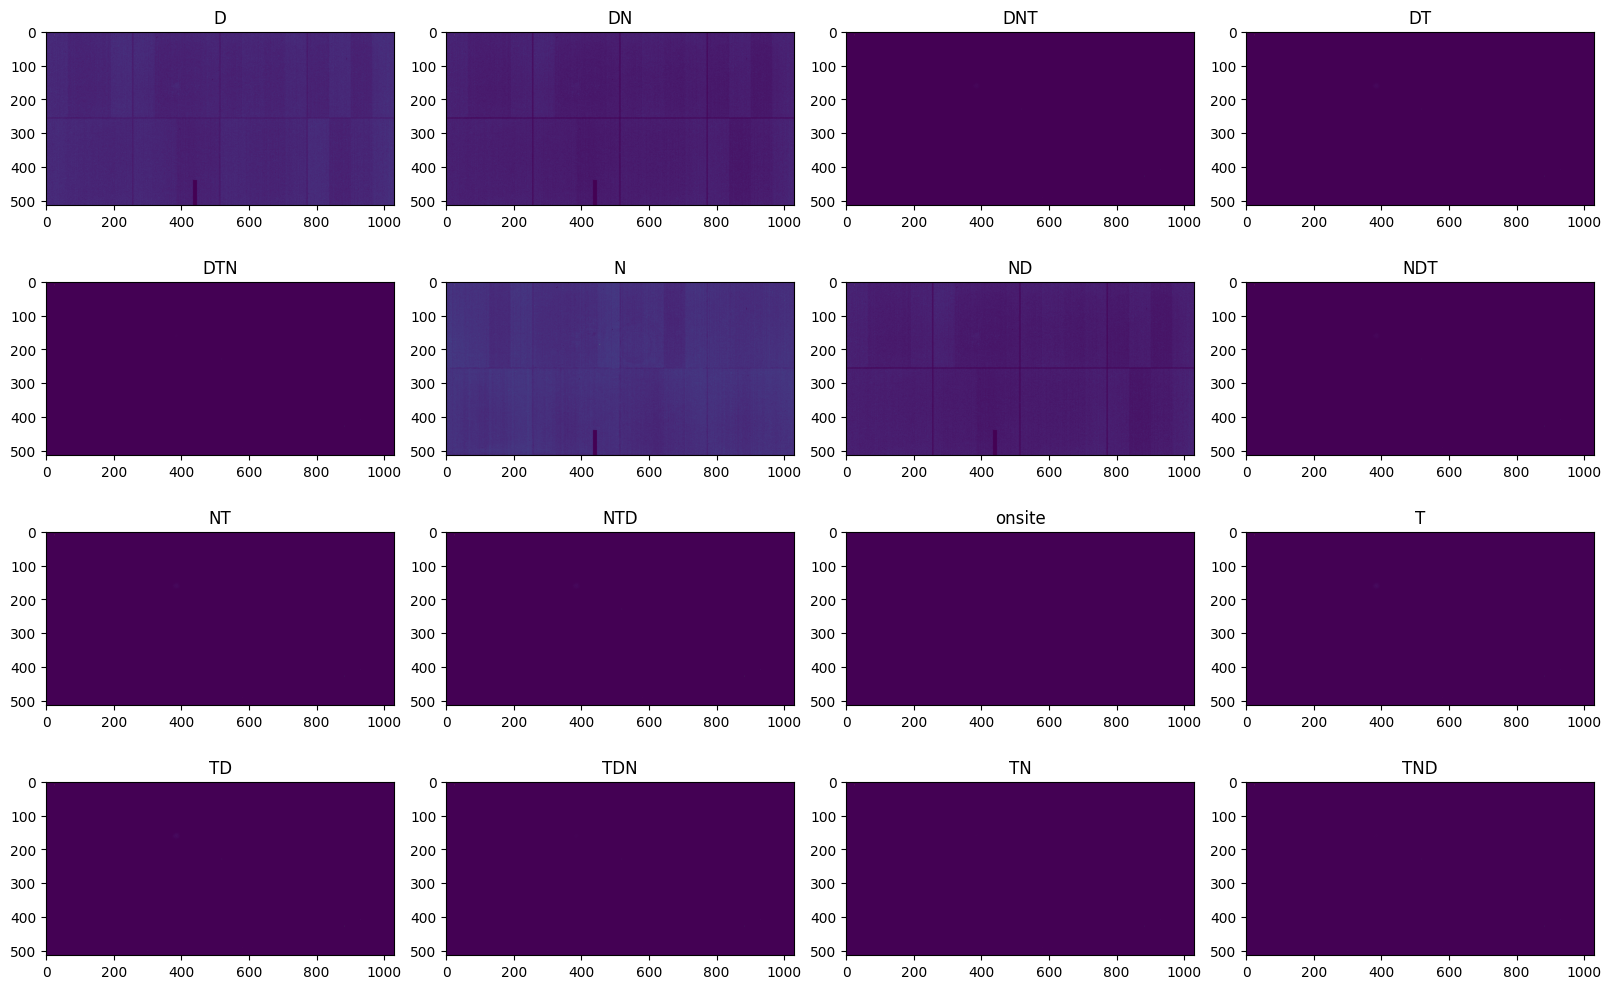

In [8]:
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt
run_n: int = 109
root: Path = Path(rf"D:\Members\JiseongOh\251128_XFEL\analysis\testing_dark\processed_data\run={run_n:03}\scan=001")
book_3d: dict[str, np.ndarray] = {}
book_2d: dict[str, np.ndarray] = {}
for file in root.glob("*.npz"):
    data_dict = np.load(file)
    imgs = data_dict.get("pon", data_dict.get("poff"))
    img = imgs.mean(0)
    name = file.stem.split("_")[-1]
    book_2d[name] = img
    book_3d[name] = imgs
    print(f"Loaded {name} with shape {imgs.shape} | mean={img.mean():.4f}, max={img.max():.4f}")


fig, axes = plt.subplots(4, 4, figsize=(16, 10), layout="constrained")
axes = axes.ravel()
for ax, (name, img) in zip(axes, book_2d.items()):
    abs_diff = np.abs(img - book_2d["onsite"])
    print(name, np.sum(abs_diff))
    ax.imshow(np.log1p(abs(img - book_2d["onsite"])))
    ax.set_title(name)


Comparison Name                | Pearson (r)  | Slope (a)    | Intercept (b) | Difference  
--------------------------------------------------------------------------------
D                              | 0.1338       | 9.3645e-01   | 1.1805e-01
DN                             | 0.1465       | 9.5518e-01   | 8.8553e-02
DNT                            | 0.9523       | 1.0766e+00   | -8.2561e-06
DT                             | 0.9554       | 1.0820e+00   | -9.7284e-07
DTN                            | 0.9404       | 1.0307e+00   | -1.8428e-05
N                              | 0.1218       | 9.5720e-01   | 1.6062e-01
ND                             | 0.1533       | 9.8392e-01   | 8.4407e-02
NDT                            | 0.9524       | 1.0773e+00   | -8.5851e-06
NT                             | 0.9533       | 1.0975e+00   | -8.0504e-06
NTD                            | 0.9748       | 1.0712e+00   | -1.0331e-05
T                              | 0.9565       | 1.1027e+00   | -7.8181e-07
TD    

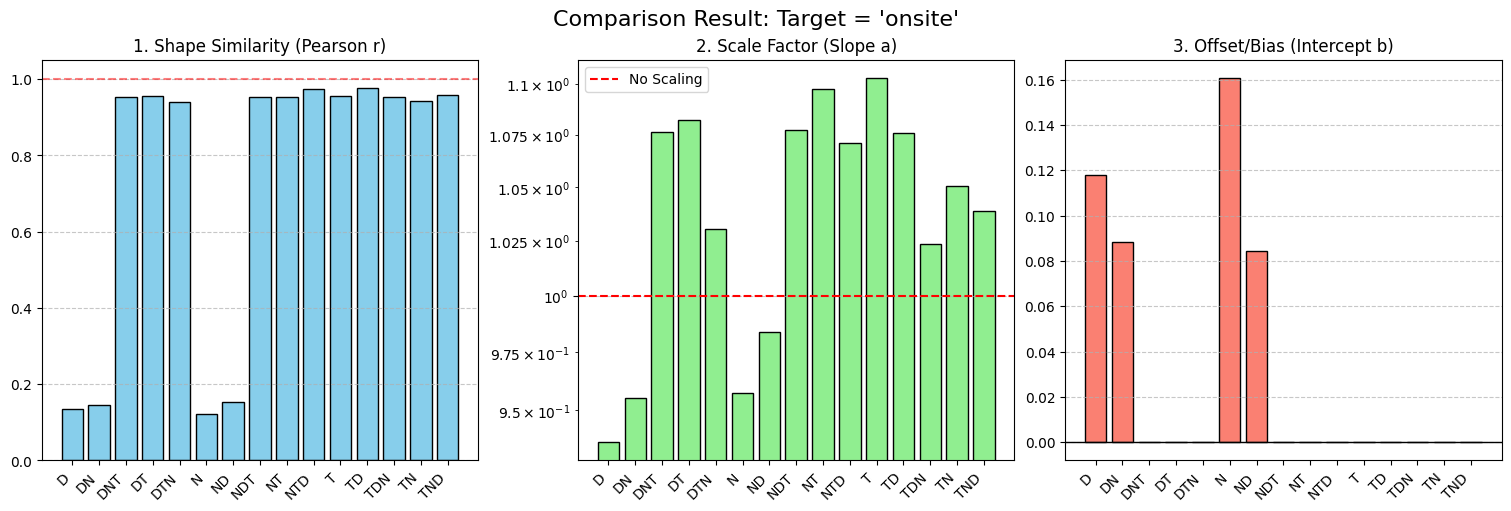

In [9]:
compare_one_to_all("onsite", book_2d)

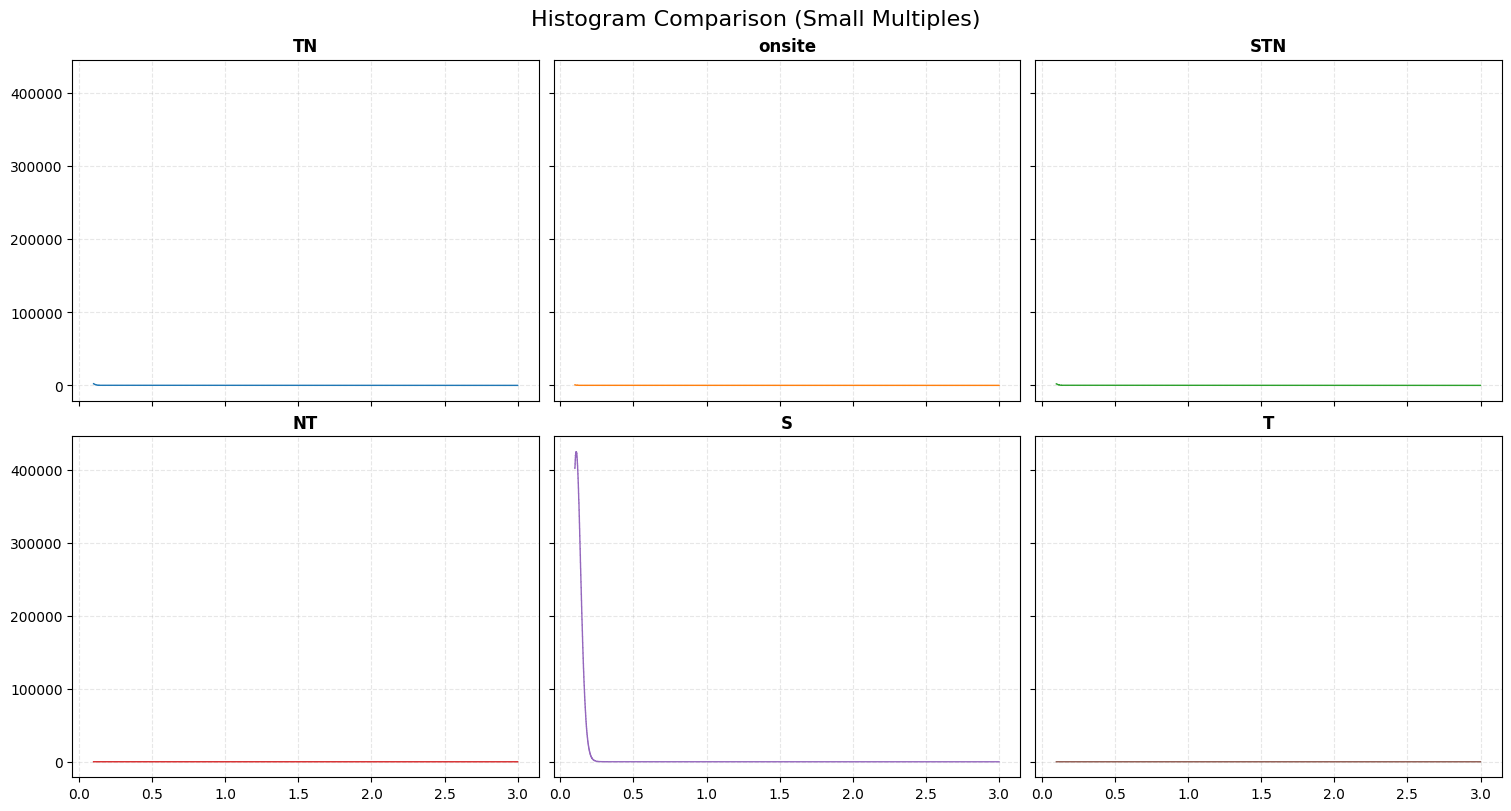

In [5]:
import matplotlib.pyplot as plt
import numpy as np

# 데이터 키 정의
keys = ["TN", "onsite", "STN", "NT", "S", "T"]

# 2행 3열 그리드 생성, x/y축 공유로 비교 용이하게 설정
fig, axes = plt.subplots(2, 3, figsize=(15, 8), sharex=True, sharey=True, constrained_layout=True)
axes = axes.flatten() # 인덱싱 편의를 위해 1차원으로 폅니다.

for i, name in enumerate(keys):
    ax = axes[i]
    data = book_3d[name]
    
    # histogram 연산
    hist, bin_edges = np.histogram(data, bins=5000, range=(0.1, 3))
    
    # [핵심] plot 대신 'step' 사용 (데이터의 계단 형상을 유지)
    # where='mid'는 빈의 중심에 값을 찍습니다.
    bin_centers = (bin_edges[:-1] + bin_edges[1:]) / 2
    ax.step(bin_centers, hist, where='mid', color=f'C{i}', linewidth=1)
    
    # 스타일링
    # ax.set_yscale("log")
    ax.set_title(name, fontweight='bold')
    ax.grid(True, which="both", ls="--", alpha=0.3)

fig.suptitle("Histogram Comparison (Small Multiples)", fontsize=16)
plt.show()